# Exam Project

Import and set magics:

In [283]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1, Problem2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Problem 1

### Question 1.a

## Problem 2

### Question 2.1

We start by finding the steady state analytically and confirm it numerically with a root-finder. We then simulate the baseline model with a constant savings rate, $s_t = \bar{s}$, and plot the paths for $s_t$, $k_t$ and $c_t$. Finally, we test the simulator with two cases where the answer is known in advance.

In [284]:
from SolowModel import SolowModelClass
import numpy as np
import matplotlib.pyplot as plt

# Create the model with the calibration from the exam
model = SolowModelClass()

# Analytical steady state for s = s_bar
k_star, y_star, c_star = model.steady_state()
print(f'analytical: k* = {k_star:.4f}, y* = {y_star:.4f}, c* = {c_star:.4f}')

# Confirm k* with a root-finder
k_star_num = model.solve_steady_state()
print(f'numerical:  k* = {k_star_num:.4f}')

assert np.isclose(k_star, k_star_num), 'analytical and numerical steady state do not agree'

analytical: k* = 0.7607, y* = 0.9129, c* = 0.6847
numerical:  k* = 0.7607


It has been shown, that the analytical and numerical steady state agree - as expected. Next, we will simulate the baseline economy for $T=100$ periods starting from $k_0=0.10$, using the constant savings rate $\bar{s}=0.25$.

c_0     = 0.3481
c_T-1   = 0.6847
k_T-1   = 0.7607


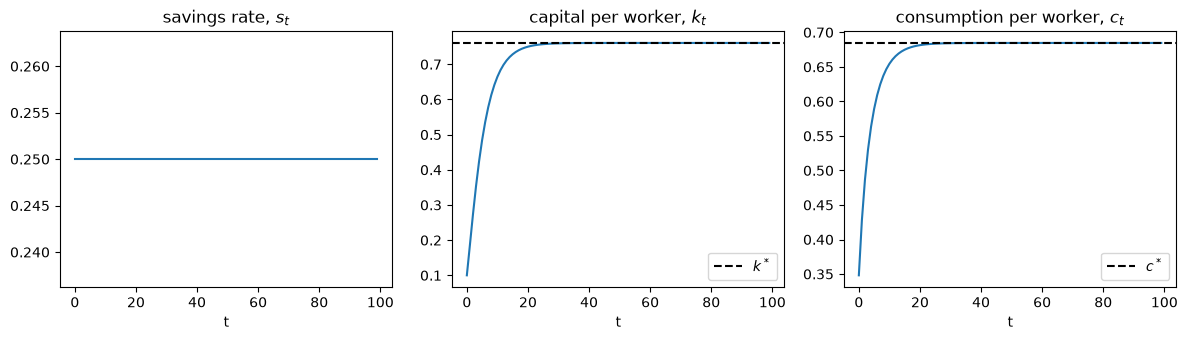

In [285]:
# Simulate the baseline with a constant savings rate
par = model.par
sim_baseline = model.simulate(s=par.s_bar)

# Report key numbers
print(f'c_0     = {sim_baseline.c[0]:.4f}')
print(f'c_T-1   = {sim_baseline.c[-1]:.4f}')
print(f'k_T-1   = {sim_baseline.k[-1]:.4f}')

# Plot s_t, k_t and c_t in three panels
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s)
axes[0].set_title('savings rate, $s_t$')
axes[0].set_xlabel('t')

axes[1].plot(t, sim_baseline.k)
axes[1].axhline(k_star, ls='--', color='black', label='$k^*$')
axes[1].set_title('capital per worker, $k_t$')
axes[1].set_xlabel('t')
axes[1].legend()

axes[2].plot(t, sim_baseline.c)
axes[2].axhline(c_star, ls='--', color='black', label='$c^*$')
axes[2].set_title('consumption per worker, $c_t$')
axes[2].set_xlabel('t')
axes[2].legend()

fig.tight_layout()
plt.show()

As seen by the plots, capital converges monotonically to $k^*$, and consumption converges to $c^*$, as the constant savings rate implies. We now test the simulator agianst two cases where the outcome is known analytically: (i) Starting exactly at the steady state should leave $k_t$ unchanged, and (ii) a zero savings rate should make capital decay geometrically at rate $(1-\delta)$.

In [286]:
# Test 1: starting at k* with s = s_bar should stay at k*
sim_at_star = model.simulate(s=par.s_bar, k0=k_star)
assert np.allclose(sim_at_star.k, k_star), 'economy starting at k* should remain there'

# Test 2: with s = 0, capital should decay as k_t = (1-delta)^t * k0
sim_zero_s = model.simulate(s=0.0)
k_analytical = (1 - par.delta)**np.arange(par.T) * par.k0
assert np.allclose(sim_zero_s.k, k_analytical), 'capital path with s=0 does not match analytical decay'

print('both assert tests passed')

both assert tests passed


### Question 2.2

We now let the savings rate vary over time according to $s_t=\bar{s} + (s_0-\bar{s})\phi^t$, and simulate the model for the four given combinations of $(s_0,\phi)$, together with the baseline.

In [287]:
import copy

# Simulate baseline (again, to be safe) and copy the result out
sim_baseline = copy.deepcopy(model.simulate(s=par.s_bar))

# Simulate each combination, copying each result out of the shared sim object
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]
sims = {}
for s0, phi in combos:
    s_vec = model.s_path(s0, phi)
    sims[(s0, phi)] = copy.deepcopy(model.simulate(s=s_vec))

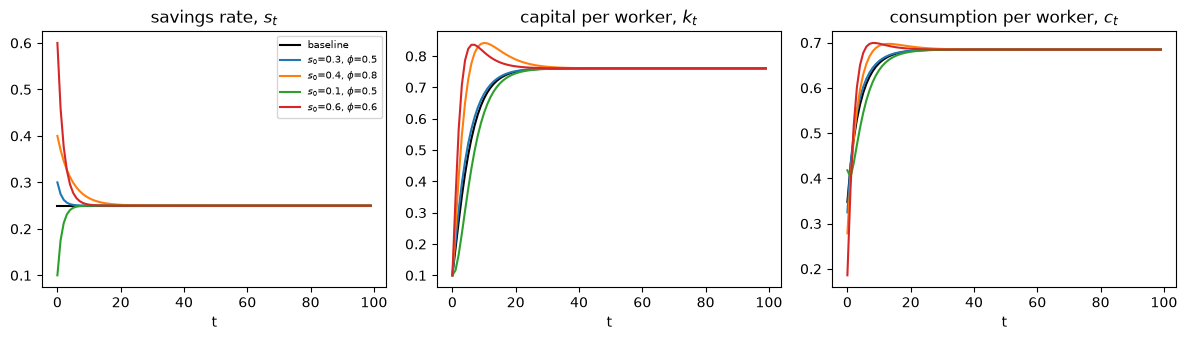

In [288]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s, color='black', label='baseline')
axes[1].plot(t, sim_baseline.k, color='black', label='baseline')
axes[2].plot(t, sim_baseline.c, color='black', label='baseline')

for (s0, phi), sim in sims.items():
    label = f'$s_0$={s0}, $\\phi$={phi}'
    axes[0].plot(t, sim.s, label=label)
    axes[1].plot(t, sim.k, label=label)
    axes[2].plot(t, sim.c, label=label)

axes[0].set_title('savings rate, $s_t$')
axes[1].set_title('capital per worker, $k_t$')
axes[2].set_title('consumption per worker, $c_t$')
for ax in axes:
    ax.set_xlabel('t')
axes[0].legend(fontsize=7)

fig.tight_layout()
plt.show()

As seen by the plots, all four combinations converge to the same steady state $k_{T-1}$ as the baseline, since $s_t \to \bar{s}$ as $t\to\infty$ regardless of $s_0$ and $\phi$. The long-run savings rate is the same in every case.

$s_0$ sets the starting point of the savings rate: A high $s_0$ means high initial investment and a faster initial buildup of capital, while a low $s_0$ means low initial investment and a slower start, temporarily below the baseline path.

$\phi$ governs the speed at which $s_t$ returns to $\bar{s}$: A high $\phi$ (close to 1) makes the deviation from $\bar{s}$ persist for a long time, while a lower $\phi$ means the savings rate reverts to $\bar{s}$ quickly, so the path looks close to the baseline after just a few periods.

### 2.3

We implement welfare as the discounted sum of log-utility, and report it for the baseline and for the four savings rules from the previous question.

In [289]:
import copy

# Welfare of the baseline
W_baseline = model.welfare(sim_baseline.c)

# Welfare of each combination, using evaluate (recomputes internally)
rows = []
for s0, phi in combos:
    W = model.evaluate(s0, phi)
    rows.append({'s0': s0, 'phi': phi, 'W': W, 'W - W_baseline': W - W_baseline})

# Collect in a small table
df = pd.DataFrame(rows)
df.loc[len(df)] = ['baseline', '-', W_baseline, 0.0]
df = df[['s0', 'phi', 'W', 'W - W_baseline']]
print(df.to_string(index=False))

      s0  phi         W  W - W_baseline
     0.3  0.5 -3.985706        0.008682
     0.4  0.8 -4.091413       -0.097025
     0.1  0.5 -4.146018       -0.151630
     0.6  0.6 -4.340653       -0.346265
baseline    - -3.994388        0.000000


The ranking is not simply a matter of $s_0 > \bar{s}$ sacrificing early consumption and $s_0 < \bar{s}$ gaining it. With $s_0=0.30$ ($>\bar s$), $c_0$ is actually lower than the baseline (0.325 vs. 0.348), since more is saved in period 0, but from $t=1$ and onward $c_t$ is higher than the baseline in every remaining period, as the extra early investment quickly raises capital and hence consumption. Weighted by $\beta^t$, this net effect is positive, so $W$ ends up above the baseline.

With $s_0=0.10$ ($<\bar s$), the opposite happens: $c_0$ is higher than the baseline (0.418 vs. 0.348), but $c_t$ falls below the baseline for many of the following periods, since capital accumulation is delayed by the low initial savings. The one-period gain at $t=0$ is outweighed by the sustained loss that follows, so $W$ ends up below the baseline.

This is why $(0.30,0.50)$ is the only one of the four combinations that beats the baseline: it is the only rule trading a small one-period loss for a sustained gain, while $(0.10,0.50)$ does the opposite, and $(0.40,0.80)$ and $(0.60,0.60)$ both deviate from $\bar s$ for too long for the early loss to be recovered within the discounted horizon.

This is harder to see directly from the Question 2 figure than the sign of $c_0$ vs. the baseline alone would suggest - it is the timing of when each curve crosses the baseline, not just the size of the initial gap, that determines the sign of $W$.

### 2.4

We compute welfare on a grid over $(s_0,\phi)$, find the best grid point, and refine it with a numerical optimizer. We then plot the best rule against the baseline.

best on grid: s0 = 0.3061, phi = 0.2327, W = -3.984371


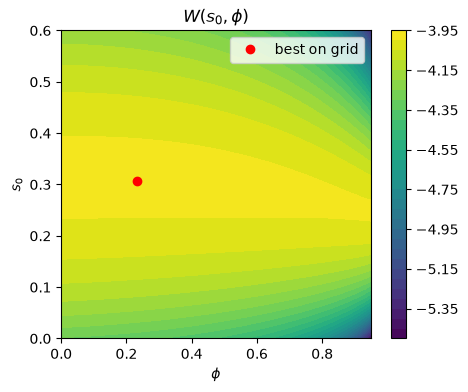

In [290]:
# Build the grid
N = 50
s0_grid = np.linspace(0, 0.60, N)
phi_grid = np.linspace(0, 0.95, N)
W_grid = np.empty((N, N))

for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = model.evaluate(s0, phi)

# Best point on the grid
idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_best_grid, phi_best_grid = s0_grid[idx[0]], phi_grid[idx[1]]
W_best_grid = W_grid[idx]
print(f'best on grid: s0 = {s0_best_grid:.4f}, phi = {phi_best_grid:.4f}, W = {W_best_grid:.6f}')

# Illustrate with contourf (note: W_grid[i,j] varies s0 along axis 0, phi along axis 1)
fig, ax = plt.subplots(figsize=(5,4))
cs = ax.contourf(phi_grid, s0_grid, W_grid, levels=30)
ax.plot(phi_best_grid, s0_best_grid, 'ro', label='best on grid')
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$s_0$')
ax.set_title('$W(s_0,\\phi)$')
fig.colorbar(cs)
ax.legend()
plt.show()

In [291]:
from scipy import optimize

# Minimize -W (since we want to maximize W)
obj = lambda x: -model.evaluate(x[0], x[1])
result = optimize.minimize(obj, x0=[s0_best_grid, phi_best_grid], method='Nelder-Mead')

s0_opt, phi_opt = result.x
W_opt = -result.fun

print(f'optimizer:  s0 = {s0_opt:.4f}, phi = {phi_opt:.4f}, W = {W_opt:.6f}')
print(f'grid:       s0 = {s0_best_grid:.4f}, phi = {phi_best_grid:.4f}, W = {W_best_grid:.6f}')
print(f'improvement over grid: {W_opt - W_best_grid:.6f}')

optimizer:  s0 = 0.3115, phi = 0.2207, W = -3.984300
grid:       s0 = 0.3061, phi = 0.2327, W = -3.984371
improvement over grid: 0.000071


The optimizer refines the grid point only slightly, with a tiny further improvement in $W$. This is expected: The grid is already fine enough to land close to the optimum, so the optimizer mainly polishes the last decimals.

c0 (best rule) = 0.3196
first t where c_t (best) > c_t (baseline): t = 1


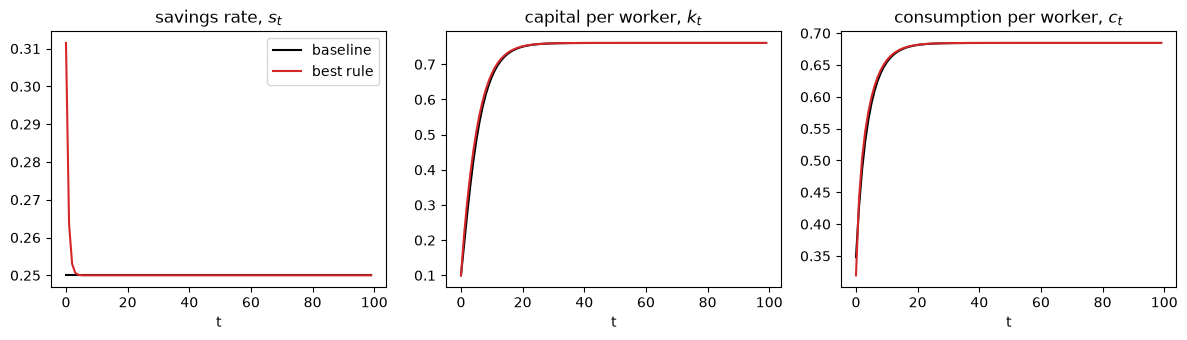

In [292]:
import copy

# Simulate the best rule
sim_best = copy.deepcopy(model.simulate(s=model.s_path(s0_opt, phi_opt)))

# Report c0 and the first period where c_best exceeds baseline
print(f'c0 (best rule) = {sim_best.c[0]:.4f}')
diff = sim_best.c - sim_baseline.c
first_above = np.argmax(diff > 0)
print(f'first t where c_t (best) > c_t (baseline): t = {first_above}')

# Plot s_t, k_t, c_t: best rule vs baseline
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(t, sim_baseline.s, color='black', label='baseline')
axes[0].plot(t, sim_best.s, color='tab:red', label='best rule')
axes[1].plot(t, sim_baseline.k, color='black', label='baseline')
axes[1].plot(t, sim_best.k, color='tab:red', label='best rule')
axes[2].plot(t, sim_baseline.c, color='black', label='baseline')
axes[2].plot(t, sim_best.c, color='tab:red', label='best rule')

axes[0].set_title('savings rate, $s_t$')
axes[1].set_title('capital per worker, $k_t$')
axes[2].set_title('consumption per worker, $c_t$')
for ax in axes:
    ax.set_xlabel('t')
axes[0].legend()

fig.tight_layout()
plt.show()

The best rule has $c_0\approx0.320$, below the baseline's $c_0\approx0.348$ - it sacrifices consumption in period 0 to save more. From $t=1$ onward, consumption is already (slightly) above the baseline and stays there, which is the mechanism identified in 2.3: A small one-period loss traded for a sustained gain, weighted by the discount factor.

The gain from the optimal rule over the baseline is small in absolute terms, and is therefore only a modest increase in savings early on. A larger or longer lasting deviation would cost more in lost early consumption than it would gain later, given how strongly early periods are weighted by $\beta$.

### 2.5

We let the long-run savings rate become a third free parameter, $s_t = s_\infty + (s_0-s_\infty)\phi^t$, and maximize $W$ over all three parameters jointly.

In [293]:
# Minimize -W over (s0, phi, s_inf), starting from the Question 4 solution
obj3 = lambda x: -model.evaluate(x[0], x[1], x[2])
x0 = [s0_opt, phi_opt, par.s_bar]

result3 = optimize.minimize(obj3, x0=x0, method='Nelder-Mead')
s0_3, phi_3, s_inf_3 = result3.x
W_3 = -result3.fun

print(f'3-parameter optimum: s0 = {s0_3:.4f}, phi = {phi_3:.4f}, s_inf = {s_inf_3:.4f}, W = {W_3:.6f}')
print(f'improvement over Question 4 (W = {W_opt:.6f}): {W_3 - W_opt:.6f}')

3-parameter optimum: s0 = 0.3139, phi = 0.6709, s_inf = 0.1989, W = -3.966965
improvement over Question 4 (W = -3.984300): 0.017335


In [294]:
import copy

sim_3 = copy.deepcopy(model.simulate(s=model.s_path(s0_3, phi_3, s_inf_3)))

print(f'k_T-1 (Question 5 best rule) = {sim_3.k[-1]:.4f}')
print(f'k* (from Question 1, s = s_bar) = {k_star:.4f}')

k_T-1 (Question 5 best rule) = 0.5400
k* (from Question 1, s = s_bar) = 0.7607


Allowing $s_\infty$ to be chosen freely gives a noticeably larger improvement in $W$ (+0.017 relative to Question 4) than restricting the long run to $\bar s=0.25$. The optimizer converges to $s_\infty\approx0.199$, below $\bar s$, together with a larger $\phi\approx0.67$: It is optimal not just to tilt savings temporarily, but to permanently settle at a lower long run savings rate than $\bar s$.

$k_{T-1}$ under this rule ($\approx0.540$) is therefore not the same as $k^*$ from question 2.1 ($\approx0.761$) - and it should not be. $k^*$ is the steady state associated with the fixed $\bar s=0.25$, whereas the question 2.5 economy converges to the steady state associated with its own, lower, $s_\infty\approx0.199$. Confirming: $(s_\infty/\delta)^{1/(1-\alpha)}$ evaluated at $s_\infty=0.199$ gives exactly $k_{T-1}\approx0.540$, so the simulation has indeed reached its (different) new steady state.

### 2.6

As an alternative to the smooth geometric decay $s_t = s_\infty+(s_0-s_\infty)\phi^t$, we propose a step (bang-bang) rule: The savings rate is held at a constant $s_{\text{early}}$ for the first $t_{\text{switch}}$ periods, then jumps directly to its long run levels $s_\infty$ and stays there. This still settles at a constant long run level, satisfying the requirement, but explores a different shape (a discontinuous jump instead of smooth decay).

$$s_t = \begin{cases} s_{\text{early}} & t < t_{\text{switch}} \\ s_\infty & t \ge t_{\text{switch}} \end{cases}$$

In [295]:
from scipy import optimize

def s_path_step(par, s_early, t_switch, s_inf):
    """ step rule: s_early for t < t_switch, then s_inf """
    t = np.arange(par.T)
    return np.where(t < t_switch, s_early, s_inf)

def evaluate_step(model, s_early, t_switch, s_inf):
    """ welfare of the step rule """
    s_vec = s_path_step(model.par, s_early, t_switch, s_inf)
    sim = model.simulate(s=s_vec)
    return model.welfare(sim.c)

# t_switch is an integer, so loop over it and optimize (s_early, s_inf) continuously for each
best = None
for t_switch in range(0, 31):
    obj = lambda x: -evaluate_step(model, x[0], t_switch, x[1])
    result = optimize.minimize(obj, x0=[0.35, 0.20], method='Nelder-Mead')
    W = -result.fun
    if best is None or W > best[0]:
        best = (W, result.x[0], t_switch, result.x[1])

W_step, s_early_best, t_switch_best, s_inf_best = best
print(f'best step rule: s_early = {s_early_best:.4f}, t_switch = {t_switch_best}, '
      f's_inf = {s_inf_best:.4f}, W = {W_step:.6f}')

best step rule: s_early = 0.2883, t_switch = 3, s_inf = 0.2087, W = -3.970790


In [296]:
comparison = pd.DataFrame([
    {'rule': 'baseline (constant s_bar)', 'W': W_baseline, 'W - W_baseline': 0.0},
    {'rule': 'Q2.4 (phi-decay, s_inf=s_bar)', 'W': W_opt, 'W - W_baseline': W_opt - W_baseline},
    {'rule': 'Q2.5 (phi-decay, free s_inf)', 'W': W_3, 'W - W_baseline': W_3 - W_baseline},
    {'rule': 'Q2.6 (step rule)', 'W': W_step, 'W - W_baseline': W_step - W_baseline},
])
print(comparison.to_string(index=False))

                         rule         W  W - W_baseline
    baseline (constant s_bar) -3.994388        0.000000
Q2.4 (phi-decay, s_inf=s_bar) -3.984300        0.010087
 Q2.5 (phi-decay, free s_inf) -3.966965        0.027422
             Q2.6 (step rule) -3.970790        0.023598


The step rule reaches $W\approx-3.9708$, an improvement of $0.0236$ over the baseline - better than question 2.4's $0.0100$, but slightly below question 2.5's $0.0274$. So it beats the fixed $s_\infty$ rule from question 2.4, but does not beat the free $s_\infty$ geometric decay from question 2.5, even though both the step rule and question 2.5 have three free parameters.

This makes sense: The optimal step rule keeps a moderately high savings rate ($s_{\text{early}}\approx0.288$) for only $t_{\text{switch}}=3$ periods before jumping straight to $s_\infty\approx0.209$ - remarkably close to question 2.5's own $s_\infty\approx0.199$. The two rules are targeting the same underlying trade-off, but the smooth geometric decay in question 2.5 apparently allocates the transition slightly more efficiently than an abrupt jump does, so it edges out the step rule.

## Problem 3: A portfolio with a risky and a safe asset

### Question 1

1. Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the seed given, and compute $R_t$.
2. Report the mean and standard deviation of $\log R_t$ across all the draws and compare them with $\mu$ and $\sigma$.
3. Make a figure with two panels showing the distribution of $R_t$ and the value of 1 invested in the risky and safe assets.

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026

shape of R: (50000, 40) = (N,T) = (50,000,40)

mean of log(R) = 0.050023   vs. mu    = 0.050000
std  of log(R) = 0.199965   vs. sigma = 0.200000

mean of R      = 1.072527   vs. exp(mu+0.5*sigma^2) = 1.072508
safe gross return, exp(r) = 1.010050
share of draws with R < exp(r) = 0.4208


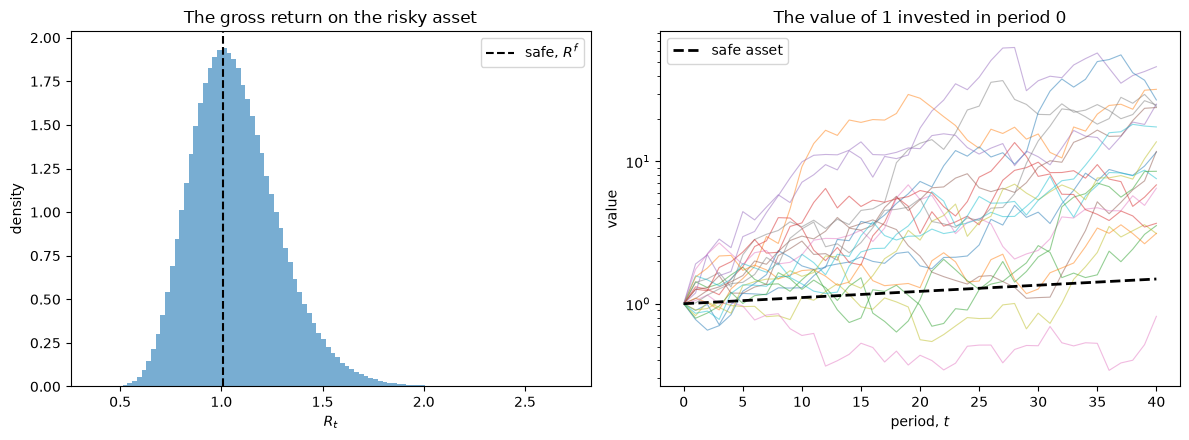

In [297]:
from PortfolioModel import PortfolioModelClass

model = PortfolioModelClass()
par = model.par
R = model.draw_returns()
log_R = np.log(R)

print(model)
print(f'\nshape of R: {R.shape} = (N,T) = ({par.N:,},{par.T})')
print(f'\nmean of log(R) = {log_R.mean():.6f}   vs. mu    = {par.mu:.6f}')
print(f'std  of log(R) = {log_R.std():.6f}   vs. sigma = {par.sigma:.6f}')
print(f'\nmean of R      = {R.mean():.6f}   vs. exp(mu+0.5*sigma^2) = {np.exp(par.mu + 0.5 * par.sigma**2):.6f}')
print(f'safe gross return, exp(r) = {np.exp(par.r):.6f}')
print(f'share of draws with R < exp(r) = {np.mean(R < np.exp(par.r)):.4f}')

n_show = 20
V_risky = np.ones((n_show, par.T + 1))
for t in range(par.T):
    V_risky[:, t + 1] = V_risky[:, t] * R[:n_show, t]
V_safe = np.exp(par.r * np.arange(par.T + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(R.ravel(), bins=100, density=True, alpha=0.6)
axes[0].axvline(np.exp(par.r), ls='--', color='black', label='safe, $R^f$')
axes[0].set(title='The gross return on the risky asset', xlabel='$R_t$', ylabel='density')
axes[0].legend()
axes[1].plot(V_risky.T, lw=0.8, alpha=0.5)
axes[1].plot(V_safe, ls='--', lw=2, color='black', label='safe asset')
axes[1].set_yscale('log')
axes[1].set(title='The value of 1 invested in period 0', xlabel='period, $t$', ylabel='value')
axes[1].legend()
fig.tight_layout()
plt.show()

The sample moments of the log return should be close to $\mu$ and $\sigma$. The mean gross return is compared with $\exp(\mu + \tfrac{1}{2}\sigma^2)$, which exceeds $\exp(\mu)$ because the exponential transformation is convex.

### Question 2

Set $\tau=0$ and compare the two extreme rules $\Delta=0$ (always trade) and $\Delta=1$ (never trade). Report the portfolio statistics and inspect how the risky-asset share evolves.

In [298]:
# Verify the two extreme rules on the same return draws.
never_trading = PortfolioModelClass(tau=0.0, Delta=1.0)
sim_never = never_trading.simulate(R)
V_risky_all = np.cumprod(R, axis=1)[:, -1]
W_T_hand = par.W0 * (par.theta_star * V_risky_all + (1 - par.theta_star) * np.exp(par.r * par.T))
assert np.allclose(sim_never.W[:, -1], W_T_hand)
assert np.all(sim_never.traded == 0.0)

always_trading = PortfolioModelClass(tau=0.0, Delta=0.0)
sim_always = always_trading.simulate(R)
W_hand = np.full(par.N, par.W0)
for t in range(par.T):
    W_hand *= par.theta_star * R[:, t] + (1 - par.theta_star) * np.exp(par.r)
assert np.allclose(sim_always.W[:, -1], W_hand)
assert np.all(sim_always.W > 0)
assert np.all((sim_always.theta >= 0) & (sim_always.theta <= 1))
print('all tests passed')

all tests passed


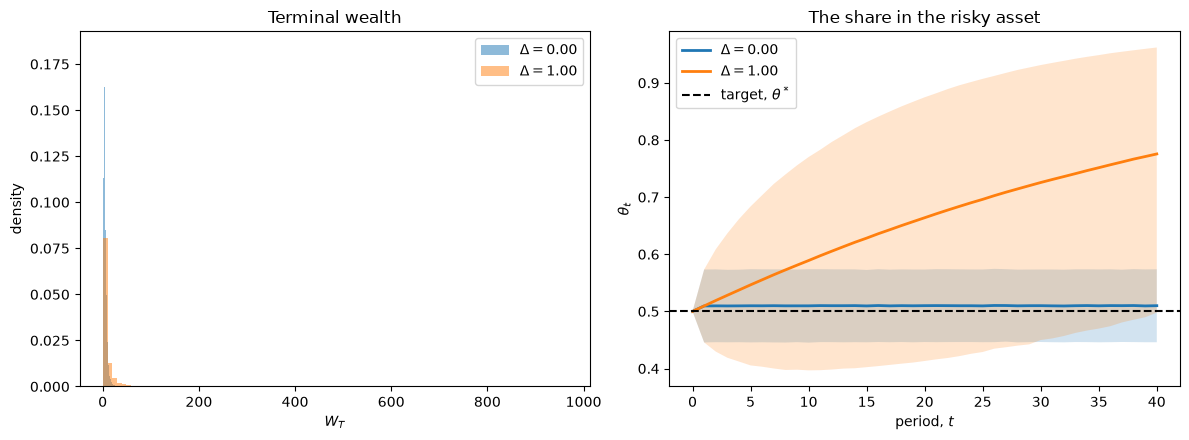

In [299]:
models = {}
for Delta in [0.0, 1.0]:
    portfolio = PortfolioModelClass(tau=0.0, Delta=Delta)
    portfolio.simulate(R)
    portfolio.summary()
    models[Delta] = portfolio

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for Delta, portfolio in models.items():
    axes[0].hist(portfolio.sim.W[:, -1], bins=100, density=True, alpha=0.5, label=f'$\\Delta = {Delta:.2f}$')
    t = np.arange(par.T + 1)
    axes[1].fill_between(t, np.percentile(portfolio.sim.theta, 10, axis=0), np.percentile(portfolio.sim.theta, 90, axis=0), alpha=0.2)
    axes[1].plot(t, portfolio.sim.theta.mean(axis=0), lw=2, label=f'$\\Delta = {Delta:.2f}$')
axes[0].set(title='Terminal wealth', xlabel='$W_T$', ylabel='density')
axes[0].legend()
axes[1].axhline(par.theta_star, ls='--', color='black', label='target, $\\theta^*$')
axes[1].set(title='The share in the risky asset', xlabel='period, $t$', ylabel='$\\theta_t$')
axes[1].legend()
fig.tight_layout()
plt.show()

With $\Delta=1$, the portfolio is never rebalanced, so the risky share changes with realized returns and dispersion grows over time. With $\Delta=0$, the portfolio is rebalanced every period and the risky share stays at the target weight.